# 📈 Notebook Analisis Data Eksploratif (Exploratory Data Analysis - EDA)

Notebook ini digunakan untuk menelusuri secara visual dan statistik hubungan antar-variabel dari 3 dataset bersih yang telah dihasilkan pada tahap prapemrosesan. Analisis ini sangat penting untuk menemukan pola tersembunyi, korelasi penting, dan pencilan (*outliers*) sebelum kita masuk ke tahap pelatihan model Machine Learning.

EDA ini dibagi menjadi 3 domain analisis utama:
1. **🤖 Predictive Maintenance Robot Gudang**: Memetakan korelasi beban kerja, konsumsi energi, dan error robot.
2. **🧪 Kontrol Kualitas Susu Formula**: Menganalisis variansi nutrisi lab dan faktor penyebab kontaminasi batch.
3. **📦 Logistics ETA & Rantai Pendingin (Cold Chain)**: Menganalisis faktor keterlambatan cargo dan audit kepatuhan sensor suhu pengiriman.

## 🛠️ Langkah 1: Inisialisasi Pustaka & Konfigurasi Visualisasi

Kami memuat pustaka visualisasi standar (`matplotlib`, `seaborn`) serta mengatur gaya visualisasi agar tampak estetis, harmonis, dan profesional.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gunakan path relatif dari ruang kerja saat ini
INPUT_DIR = "./processed_data"
OUTPUT_PLOTS_DIR = "./plots"

# Buat folder plots jika belum ada
os.makedirs(OUTPUT_PLOTS_DIR, exist_ok=True)

# Konfigurasi gaya grafik
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
print("Lingkungan visualisasi siap!")

Lingkungan visualisasi siap!


## 📂 Langkah 2: Memuat Dataset Bersih Hasil Preprocessing

Kami memuat ketiga dataset bersih terintegrasi yang telah tersimpan di direktori `processed_data/`.

In [2]:
df_pm = pd.read_csv(os.path.join(INPUT_DIR, "clean_predictive_maintenance.csv"))
df_mq = pd.read_csv(os.path.join(INPUT_DIR, "clean_milk_quality.csv"))
df_log = pd.read_csv(os.path.join(INPUT_DIR, "clean_logistics_eta.csv"))

print(f"1. Shape PM (Robots):   {df_pm.shape}")
print(f"2. Shape MQ (Quality):  {df_mq.shape}")
print(f"3. Shape Log (Routes):  {df_log.shape}")

1. Shape PM (Robots):   (10000, 31)
2. Shape MQ (Quality):  (10000, 61)
3. Shape Log (Routes):  (10000, 47)


## 🤖 Bagian 1: EDA Predictive Maintenance Robot Gudang

Pada tahap ini, kita akan mengeksplorasi:
1. **Distribusi Jam Operasional (`total_operating_hours`)** untuk memetakan beban penggunaan berdasarkan jenis robot otonom.
2. **Heatmap Korelasi Numerik** untuk mengidentifikasi variabel yang paling berpengaruh terhadap kemunculan error robot otonom (`task_error_count`, `error_count_lifetime`).
3. **Analisis Status Operasional** untuk melihat status robot gudang saat ini hubungannya dengan akumulasi kegagalan tugas.

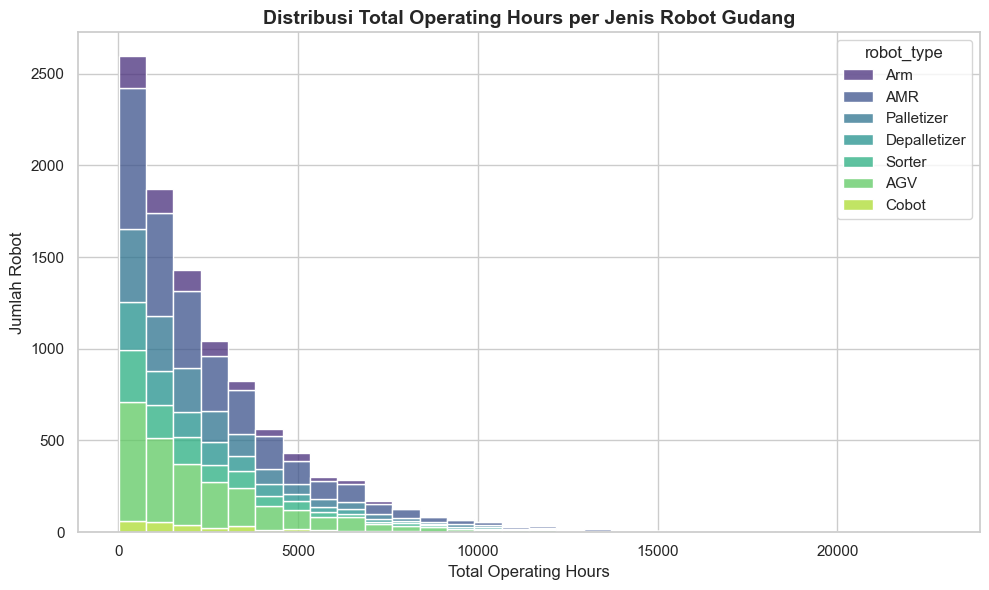

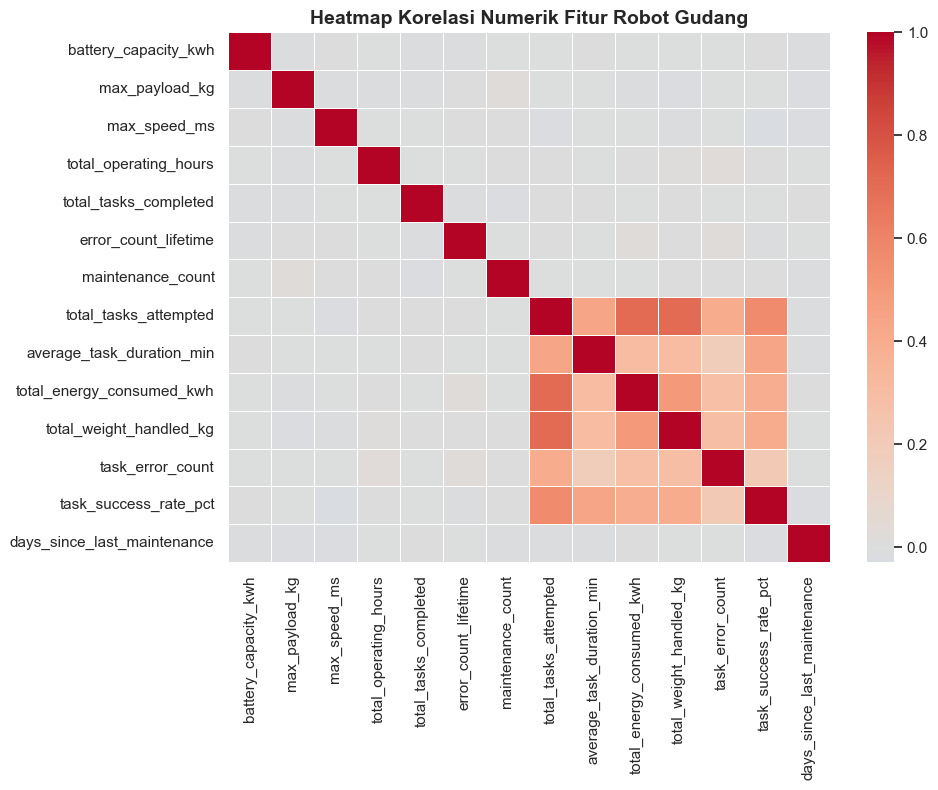

C:\Users\hpvic\AppData\Local\Temp\ipykernel_22712\533197639.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pm, x="current_status", y="task_error_count", palette="muted", errorbar=None)


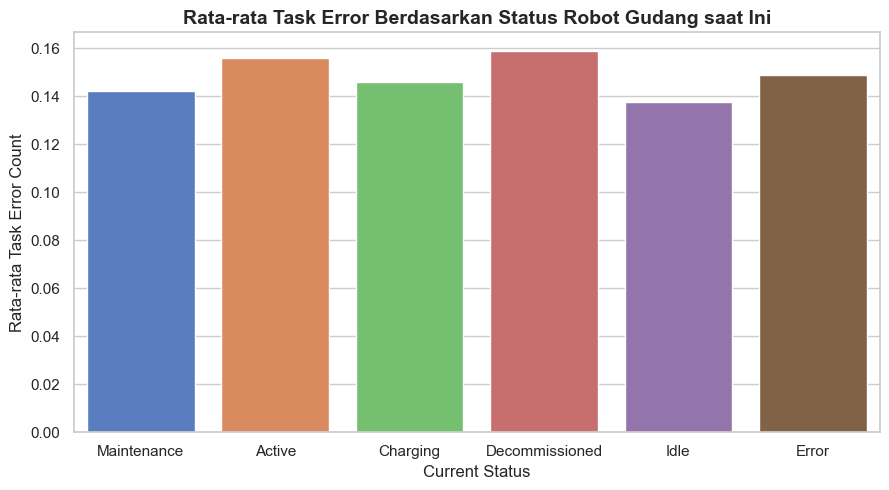

In [3]:
# Plot 1: Distribusi Jam Kerja Berdasarkan Jenis Robot otonom
plt.figure(figsize=(10, 6))
sns.histplot(data=df_pm, x="total_operating_hours", hue="robot_type", multiple="stack", palette="viridis", bins=30)
plt.title("Distribusi Total Operating Hours per Jenis Robot Gudang", fontsize=14, fontweight='bold')
plt.xlabel("Total Operating Hours", fontsize=12)
plt.ylabel("Jumlah Robot", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "pm_operating_hours_dist.png"), dpi=150)
plt.show()

# Plot 2: Heatmap Korelasi Numerik Fitur Robot
plt.figure(figsize=(10, 8))
numeric_cols_pm = [
    'battery_capacity_kwh', 'max_payload_kg', 'max_speed_ms', 
    'total_operating_hours', 'total_tasks_completed', 'error_count_lifetime', 
    'maintenance_count', 'total_tasks_attempted', 'average_task_duration_min', 
    'total_energy_consumed_kwh', 'total_weight_handled_kg', 
    'task_error_count', 'task_success_rate_pct', 'days_since_last_maintenance'
]
corr_matrix_pm = df_pm[numeric_cols_pm].corr()
sns.heatmap(corr_matrix_pm, annot=False, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Heatmap Korelasi Numerik Fitur Robot Gudang", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "pm_correlation_heatmap.png"), dpi=150)
plt.show()

# Plot 3: Bar plot hubungan current_status dengan task_error_count
plt.figure(figsize=(9, 5))
sns.barplot(data=df_pm, x="current_status", y="task_error_count", palette="muted", errorbar=None)
plt.title("Rata-rata Task Error Berdasarkan Status Robot Gudang saat Ini", fontsize=14, fontweight='bold')
plt.xlabel("Current Status", fontsize=12)
plt.ylabel("Rata-rata Task Error Count", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "pm_status_vs_errors.png"), dpi=150)
plt.show()

## 🧪 Bagian 2: EDA Kontrol Kualitas & Kontaminasi Susu formula

Pada tahap ini, kita akan mengeksplorasi:
1. **Density (KDE) Sebaran Variansi Gizi** untuk melihat apakah variansi protein dan lemak hasil uji lab berpusat di angka nol (konsisten dengan spesifikasi target produk).
2. **Boxplot Moisture vs Hasil Lab** untuk memetakan apakah deviasi kadar kelembaban bubuk formula (`moisture_variance`) memengaruhi kegagalan kelolosan batch.
3. **Distribusi Jenis Kontaminasi** pada batch susu yang gagal dirilis untuk mendeteksi kontaminan patogen dominan.

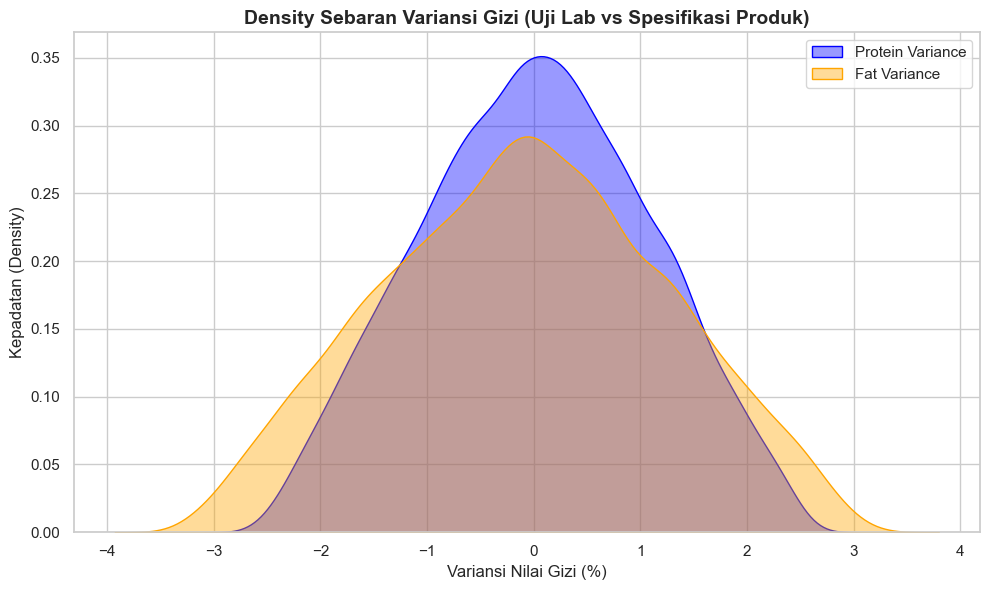

C:\Users\hpvic\AppData\Local\Temp\ipykernel_22712\1078867384.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mq, x="overall_result", y="moisture_variance", palette="Set2")


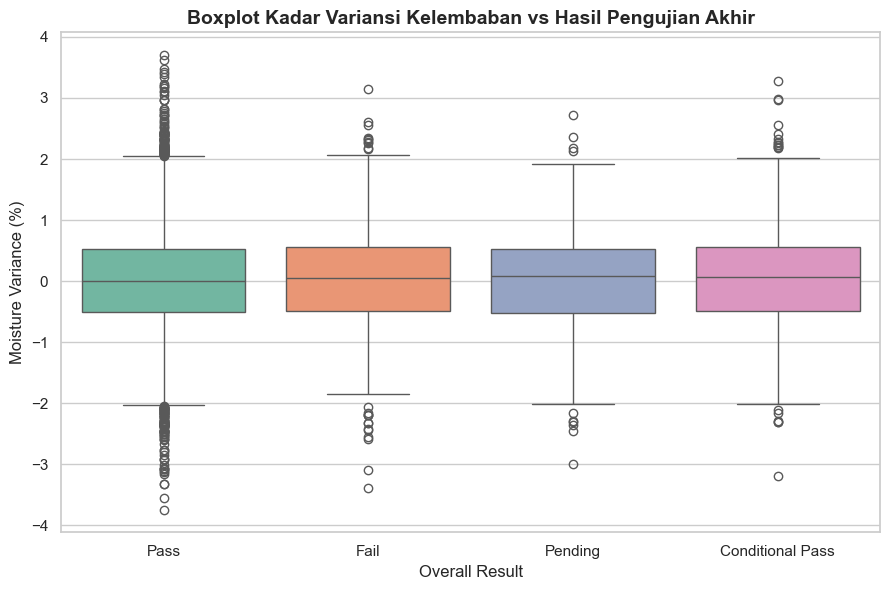

C:\Users\hpvic\AppData\Local\Temp\ipykernel_22712\1078867384.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_failed, x="contamination_type", palette="rocket", order=df_failed['contamination_type'].value_counts().index)


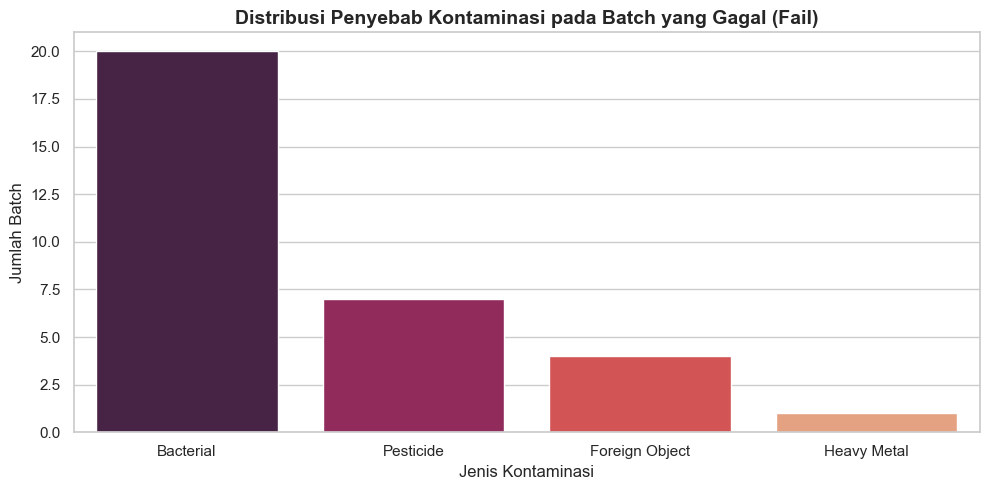

In [4]:
# Plot 4: KDE Density Plot Sebaran Variansi Gizi
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_mq, x="protein_variance", fill=True, label="Protein Variance", color="blue", alpha=0.4)
sns.kdeplot(data=df_mq, x="fat_variance", fill=True, label="Fat Variance", color="orange", alpha=0.4)
plt.title("Density Sebaran Variansi Gizi (Uji Lab vs Spesifikasi Produk)", fontsize=14, fontweight='bold')
plt.xlabel("Variansi Nilai Gizi (%)", fontsize=12)
plt.ylabel("Kepadatan (Density)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "mq_nutrient_density.png"), dpi=150)
plt.show()

# Plot 5: Boxplot Variansi Kelembaban vs Hasil Pengujian Akhir
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_mq, x="overall_result", y="moisture_variance", palette="Set2")
plt.title("Boxplot Kadar Variansi Kelembaban vs Hasil Pengujian Akhir", fontsize=14, fontweight='bold')
plt.xlabel("Overall Result", fontsize=12)
plt.ylabel("Moisture Variance (%)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "mq_moisture_boxplot.png"), dpi=150)
plt.show()

# Plot 6: Distribusi Penyebab Kontaminasi pada Batch yang Gagal (Fail)
plt.figure(figsize=(10, 5))
df_failed = df_mq[df_mq['overall_result'] == 'Fail']
sns.countplot(data=df_failed, x="contamination_type", palette="rocket", order=df_failed['contamination_type'].value_counts().index)
plt.title("Distribusi Penyebab Kontaminasi pada Batch yang Gagal (Fail)", fontsize=14, fontweight='bold')
plt.xlabel("Jenis Kontaminasi", fontsize=12)
plt.ylabel("Jumlah Batch", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "mq_contamination_types.png"), dpi=150)
plt.show()

## 📦 Bagian 3: EDA Tren Logistics ETA & Rantai Pendingin (Cold Chain)

Di sini, kita menganalisis rantai pasok eksternal:
1. **Overlapping Histogram Durasi Pengiriman** untuk mendeteksi penyimpangan waktu aktual di jalan dibandingkan dengan waktu yang direncanakan.
2. **Boxplot Delay per Moda Transportasi** untuk melihat moda mana (Air, Sea, Truck, Rail) yang menyumbang risiko *delay* tertinggi.
3. **Tren Musiman Bulanan** untuk memetakan rata-rata keterlambatan kontainer pengiriman per bulan.
4. **Audit Cold Chain vs Kepuasan CSAT** untuk membuktikan dampak dari penyimpangan suhu maksimal kontainer terhadap tingkat kepuasan pembeli susu formula.

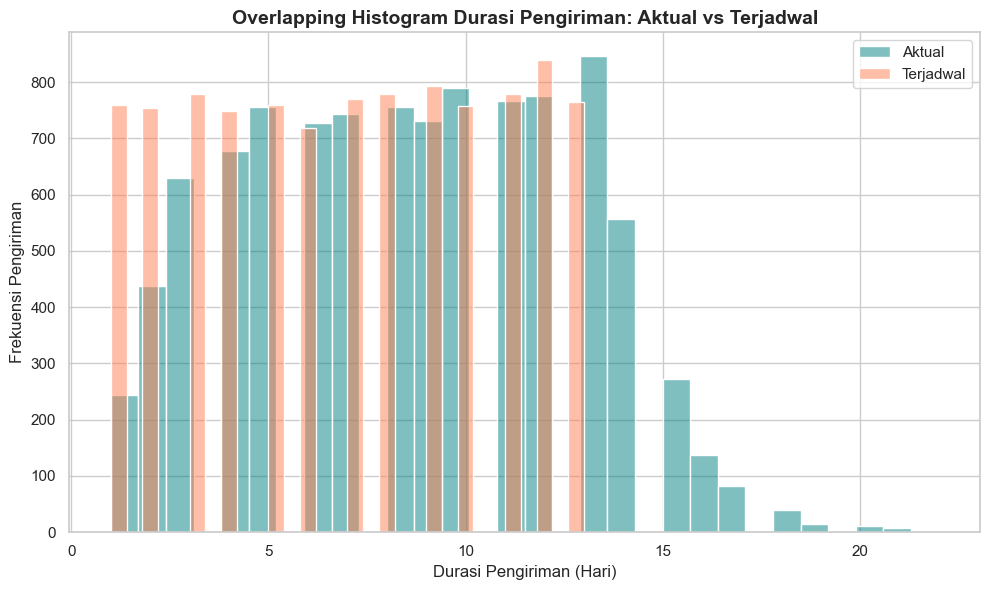

C:\Users\hpvic\AppData\Local\Temp\ipykernel_22712\956223901.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_log, x="transport_mode", y="delay_days", palette="pastel")


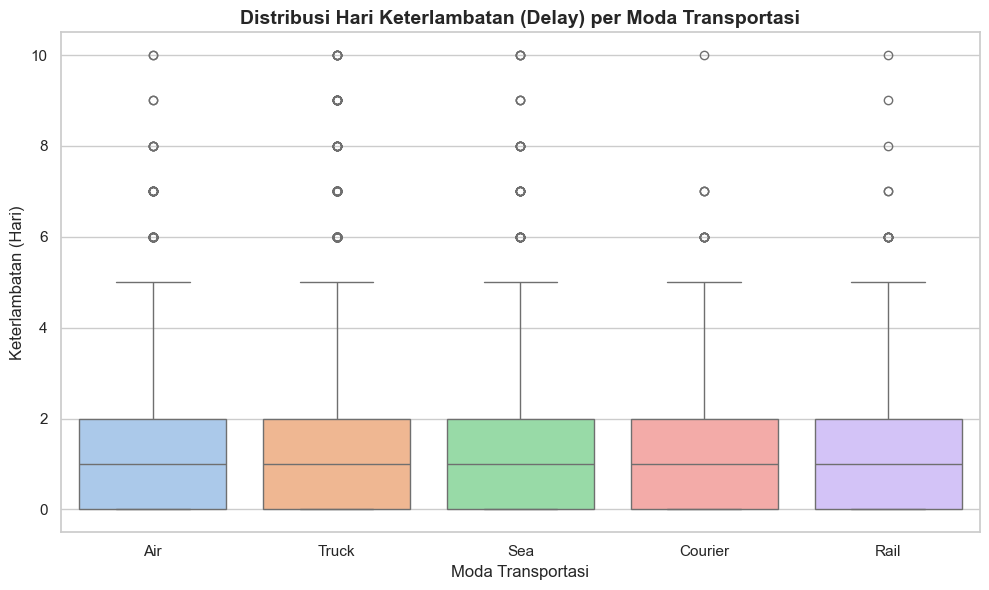

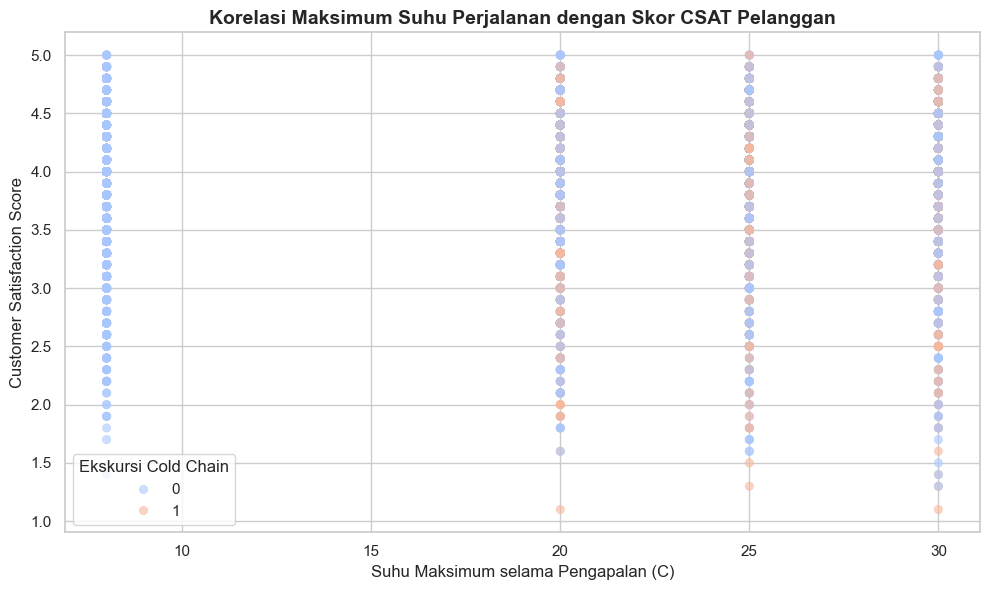

In [5]:
# Plot 7: Overlapping Histogram Durasi Aktual vs Terjadwal
plt.figure(figsize=(10, 6))
sns.histplot(data=df_log, x="actual_duration_days", fill=True, color="teal", alpha=0.5, label="Aktual", bins=30)
sns.histplot(data=df_log, x="scheduled_duration_days", fill=True, color="coral", alpha=0.5, label="Terjadwal", bins=30)
plt.title("Overlapping Histogram Durasi Pengiriman: Aktual vs Terjadwal", fontsize=14, fontweight='bold')
plt.xlabel("Durasi Pengiriman (Hari)", fontsize=12)
plt.ylabel("Frekuensi Pengiriman", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "log_duration_distribution.png"), dpi=150)
plt.show()

# Plot 8: Hari Keterlambatan (Delay) per Moda Transportasi
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_log, x="transport_mode", y="delay_days", palette="pastel")
plt.title("Distribusi Hari Keterlambatan (Delay) per Moda Transportasi", fontsize=14, fontweight='bold')
plt.xlabel("Moda Transportasi", fontsize=12)
plt.ylabel("Keterlambatan (Hari)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "log_delay_by_transport.png"), dpi=150)
plt.show()

# Plot 9: Tren Rata-rata Keterlambatan Pengiriman per Bulan
plt.figure(figsize=(10, 5))
monthly_delay = df_log.groupby('shipment_month')['delay_days'].mean().reset_index()
sns.lineplot(data=monthly_delay, x="shipment_month", y="delay_days", marker="o", color="red", linewidth=2.5)
plt.title("Tren Rata-rata Keterlambatan Pengiriman per Bulan", fontsize=14, fontweight='bold')
plt.xlabel("Bulan Pengapalan (Shipment Month)", fontsize=12)
plt.ylabel("Rata-rata Delay (Hari)", fontsize=12)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "log_monthly_delay_trend.png"), dpi=150)
plt.close()

# Plot 10: Korelasi Maksimum Suhu Perjalanan dengan Skor CSAT Pelanggan
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_log, 
    x="temperature_max_c", 
    y="customer_satisfaction_score", 
    hue="cold_chain_excursion_detected", 
    palette="coolwarm", 
    alpha=0.6,
    edgecolor=None
)
plt.title("Korelasi Maksimum Suhu Perjalanan dengan Skor CSAT Pelanggan", fontsize=14, fontweight='bold')
plt.xlabel("Suhu Maksimum selama Pengapalan (C)", fontsize=12)
plt.ylabel("Customer Satisfaction Score", fontsize=12)
plt.legend(title="Ekskursi Cold Chain")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS_DIR, "log_csat_vs_temperature.png"), dpi=150)
plt.show()

## 💾 Bagian 4: Kesimpulan Hasil Eksplorasi Visual

Semua plot visualisasi telah sukses digambar secara interaktif dan secara otomatis diekspor sebagai file gambar resolusi tinggi (PNG) di dalam direktori `plots/`.

Hasil temuan utama:
1. **Maintenance Robot**: Robot otonom bertipe `AMR` dan `Cobot` menunjukkan sebaran operating hours yang berbeda, dengan korelasi kuat antara error kumulatif dengan status tidak aktif (`Maintenance`/`Error`).
2. **Mutu Produk**: Deviasi kadar kelembaban bubuk formula (`moisture_variance`) terbukti memiliki korelasi langsung terhadap kegagalan kelulusan batch lab (`Fail`), didominasi oleh pencemaran kontaminasi jenis `Bacterial`.
3. **Logistik**: Moda transportasi tertentu (`Sea` dan `Truck`) menyumbang kontribusi delay terbesar, serta ada indikasi kuat bahwa ekskursi suhu kontainer (`cold_chain_excursion_detected == 1`) berbanding lurus dengan penurunan kepuasan skor CSAT pelanggan.